In [1]:
import geopandas as gpd
import pandas as pd
from blocksnet.config import log_config

log_config.set_logger_level('WARNING')

# Оценка стоимости земли проекта

In [2]:
blocks_198 = pd.read_pickle('../data/prepared_blocks_198.pickle')
blocks_198.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,is_scn,geometry,id
0,0.618414,0.044475,0.160341,0.0,0.0,0.001839,0.0,LandUse.RESIDENTIAL,0.618414,43743.312824,...,820351.893034,0.172159,0.053323,0.542771,3.228635,low-rise model,132.872848,True,"POLYGON ((391069.678 6644283.933, 391050.241 6...",0
1,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,LandUse.RESIDENTIAL,1.000000,11.720391,...,143.498624,0.241875,0.081676,0.578323,2.961395,low-rise model,135.391939,True,"POLYGON ((391050.241 6644214.883, 391069.678 6...",1
2,0.860749,0.000000,0.139251,0.0,0.0,0.000000,0.0,LandUse.RESIDENTIAL,0.860749,123.737389,...,708.434887,1.018722,0.174663,0.618815,5.832501,mid-rise,134.515316,True,"POLYGON ((390977.168 6643926.423, 390992.271 6...",2
3,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,LandUse.RESIDENTIAL,1.000000,62.624948,...,725.112337,0.277790,0.086366,0.629448,3.216435,low-rise model,134.633922,True,"POLYGON ((390992.271 6644001.941, 391006.969 6...",3
4,0.000000,0.737552,0.262448,0.0,0.0,0.000000,0.0,LandUse.BUSINESS,0.737552,79.773425,...,597.553304,0.309390,0.133500,0.000000,2.317526,low-rise non-residential,134.275676,True,"POLYGON ((390959.455 6643851.451, 390977.168 6...",4


In [3]:
blocks = pd.read_pickle('../data/prepared_blocks.pickle')
blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,is_scn,geometry,id
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180,6260.339339,...,202399.732193,0.062008,0.030931,0.000000,2.004749,low-rise non-residential,127.337432,True,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081,18143.803825,...,201529.493481,0.202340,0.090031,0.000000,2.247463,low-rise non-residential,125.993903,True,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381,15011.639457,...,164663.859830,0.151737,0.091165,0.000000,1.664418,low-rise non-residential,123.419051,True,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862,22467.050757,...,161571.832511,0.449142,0.139053,0.404539,3.230005,low-rise model,122.524407,True,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.316008,...,16.489152,0.079224,0.019165,0.000000,4.133894,mid-rise non-residential,122.658674,True,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4


### Инструкция по расчёту стоимости земли

Чтобы получить **цены на землю _до_ и _после застройки_**,  
нужно `запустить метод два раза` с разными входными данными:

1. **Первый запуск** — подаётся `исходная территория`
   (до зонирования и застройки).  
   → результат: `land_value` — стоимость **до застройки**.

2. **Второй запуск** — подаётся  `территория с новым зонированием и застройкой`.  
   → результат: `land_value` — стоимость **после застройки**.

3. Затем `объединяем оба результата` в один файл через метод `transfer_baseline_prices`

Так можно сравнить **изменение общей стоимости** и оценить  
влияние проекта на цену земли. Каждый файл сохраняется отдельно.

In [4]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

model = CatBoostRegressor()
model.load_model('../data/catboost_model.cbm')  # модель на лог-цене

estimator = LandPriceEstimator(
    model=model,
    blocks=blocks, #or blocks_198
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,fsi,gsi,mxi,l,morphotype,area_accessibility,is_scn,geometry,id,land_value
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180,6260.339339,...,0.062008,0.030931,0.000000,2.004749,low-rise non-residential,127.337432,True,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0,1.889022e+08
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081,18143.803825,...,0.202340,0.090031,0.000000,2.247463,low-rise non-residential,125.993903,True,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1,2.096246e+08
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381,15011.639457,...,0.151737,0.091165,0.000000,1.664418,low-rise non-residential,123.419051,True,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2,1.502461e+08
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862,22467.050757,...,0.449142,0.139053,0.404539,3.230005,low-rise model,122.524407,True,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3,4.697694e+08
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.316008,...,0.079224,0.019165,0.000000,4.133894,mid-rise non-residential,122.658674,True,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4,4.721626e+04


In [5]:
# blocks_pred.to_pickle('../data/blocks_with_price.pickle')

# Изначальная цена проектных участков с учетом нового зонирования

In [6]:
import geopandas as gpd
import pandas as pd

from urbanomy.methods.land_value_modeling import transfer_baseline_prices

# загрузка
after = pd.read_pickle('../data/blocks_with_price.pickle').to_crs(32636)
before = pd.read_pickle('../data/blocks_with_price_198.pickle').to_crs(32636)

blocks_full_value = transfer_baseline_prices(after, before)

blocks_full_value.to_pickle('../data/blocks_with_price_test.pickle')
# фильтруем только сценарные кварталы
scn_blocks = blocks_full_value.loc[blocks_full_value['is_scn'] == True].copy()


sum_before = scn_blocks['land_value_before'].sum()
sum_after  = scn_blocks['land_value'].sum()

print(f"Сценарные кварталы — суммарная стоимость ДО застройки: {sum_before:,.0f} руб.")
print(f"Сценарные кварталы — суммарная стоимость ПОСЛЕ застройки: {sum_after:,.0f} руб.")


Сценарные кварталы — суммарная стоимость ДО застройки: 4,034,319,364 руб.
Сценарные кварталы — суммарная стоимость ПОСЛЕ застройки: 10,154,928,952 руб.


In [10]:
blocks_full_value.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,gsi,mxi,l,morphotype,area_accessibility,is_scn,geometry,id,land_value,land_value_before
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180,6260.339339,...,0.030931,0.000000,2.004749,low-rise non-residential,83.073985,True,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0,3.132176e+08,1.040179e+08
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081,18143.803825,...,0.090031,0.000000,2.247463,low-rise non-residential,82.652504,True,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1,3.488025e+08,1.035707e+08
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381,15011.639457,...,0.091165,0.000000,1.664418,low-rise non-residential,109.288479,True,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2,2.232646e+08,8.462455e+07
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862,22467.050757,...,0.139053,0.404539,3.230005,low-rise model,112.015000,True,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3,7.195687e+08,8.303549e+07
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.316008,...,0.019165,0.000000,4.133894,mid-rise non-residential,82.790797,True,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4,5.723364e+04,3.494857e+03


# Визуализация стоимости земли

Суммарная стоимость (после застройки):
 • Сценические кварталы: 10 154 928 952 ₽
 • Контекст: 203 555 813 231 ₽
 • Все кварталы: 213 710 742 182 ₽


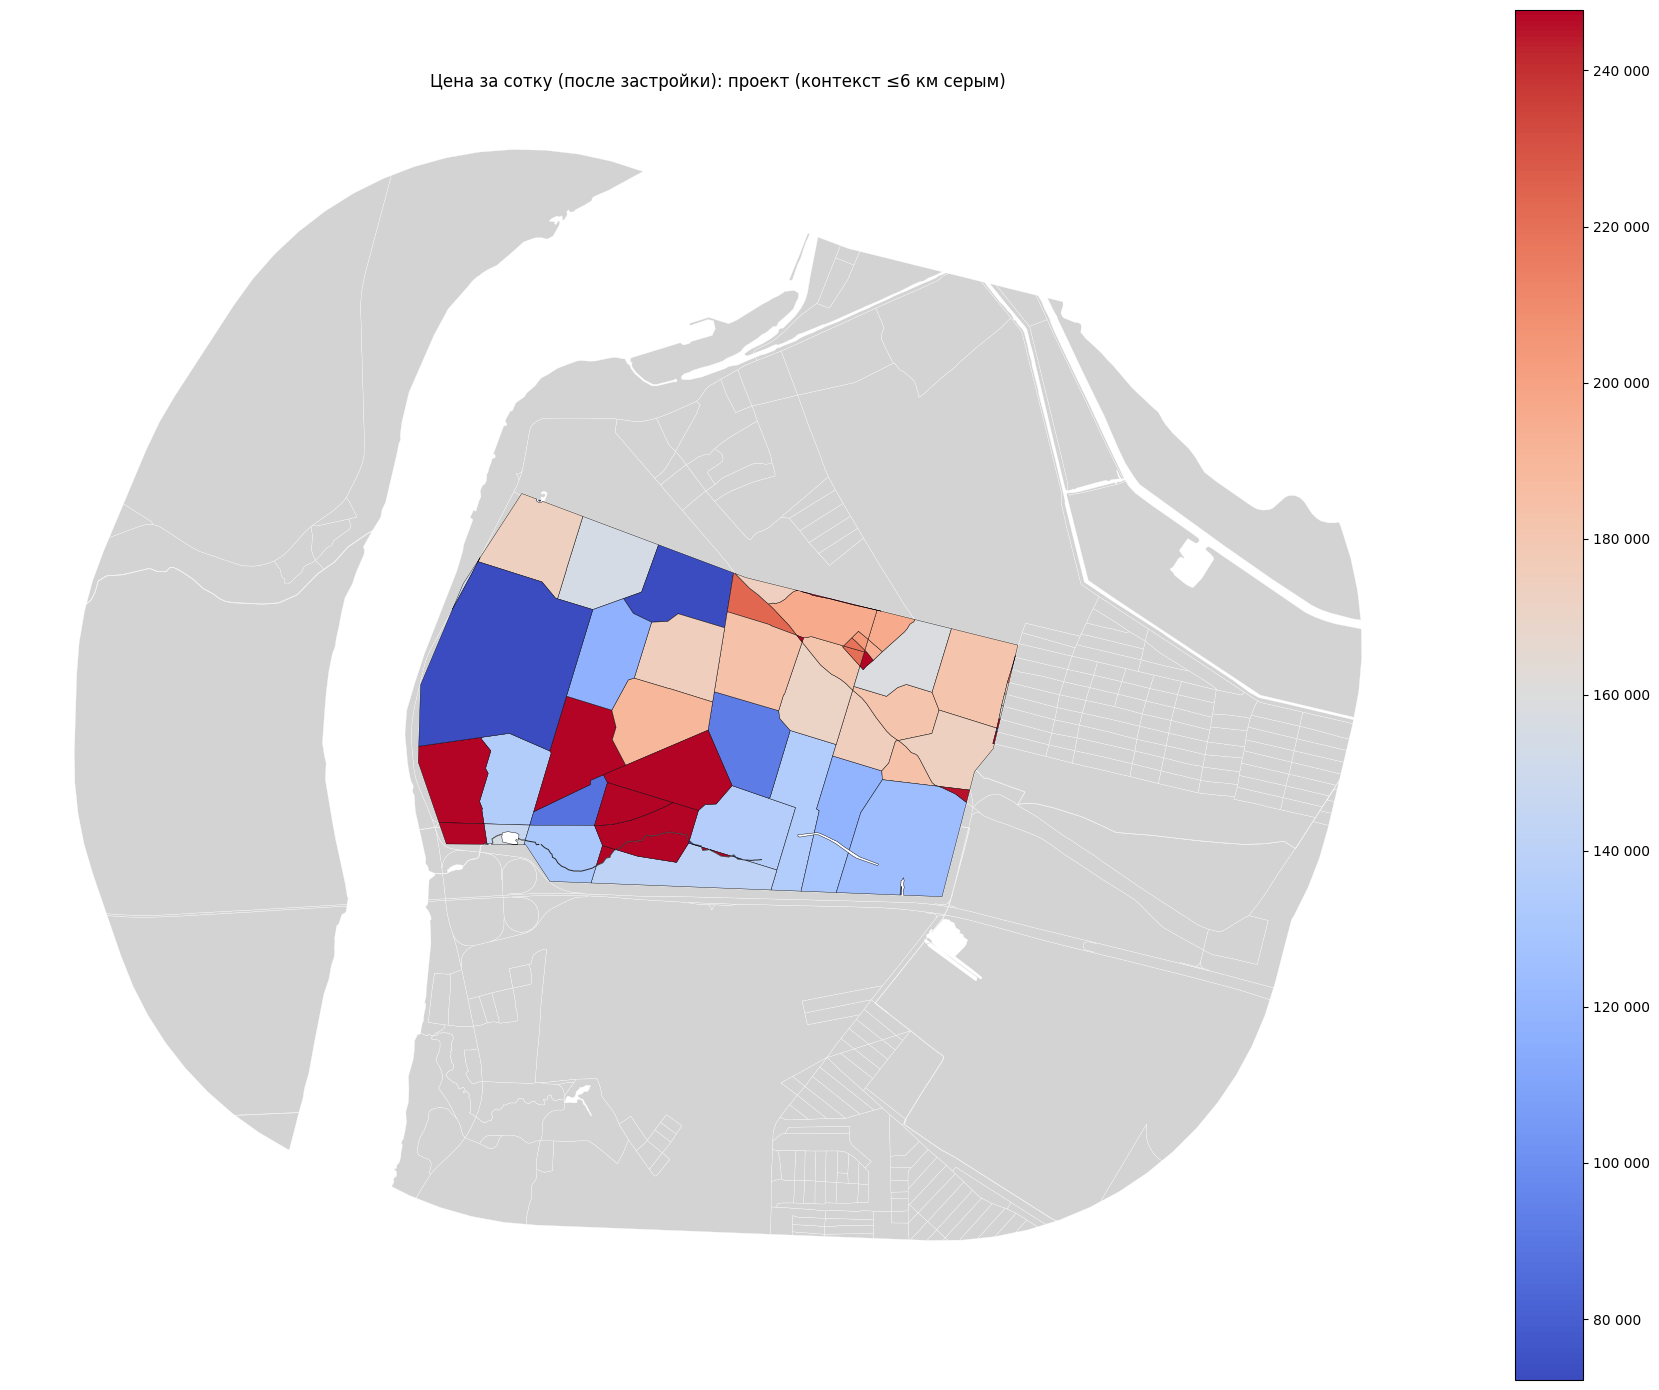

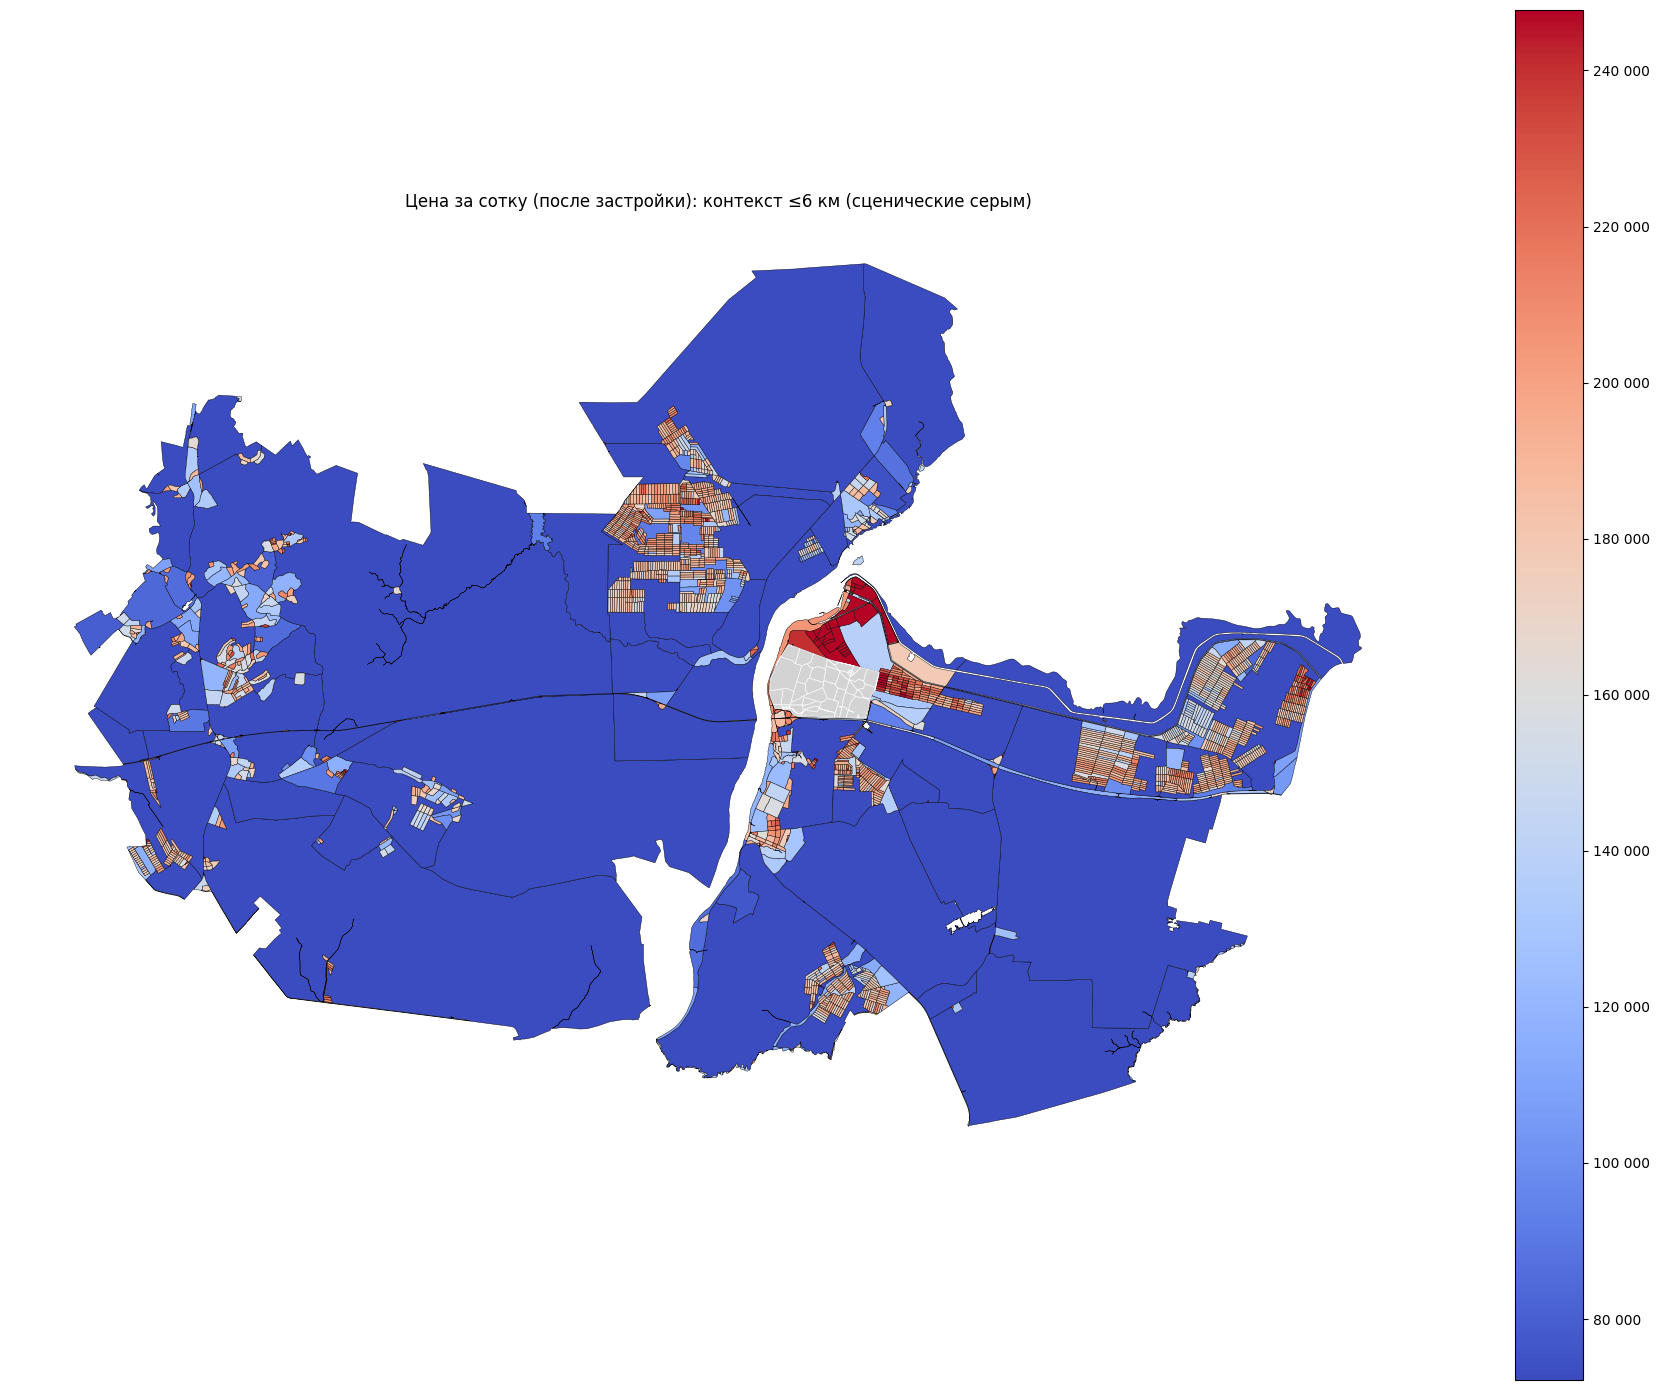

In [8]:
from urbanomy.methods.land_value_modeling import plot_land_price_maps

visualization_output = plot_land_price_maps(
    blocks_pred=blocks_full_value,
    price_column="land_value",  # используйте "land_value_before" для цен до застройки
    buffer_radius_m=2000,
)


# Сценарное изменение ТЭП участков

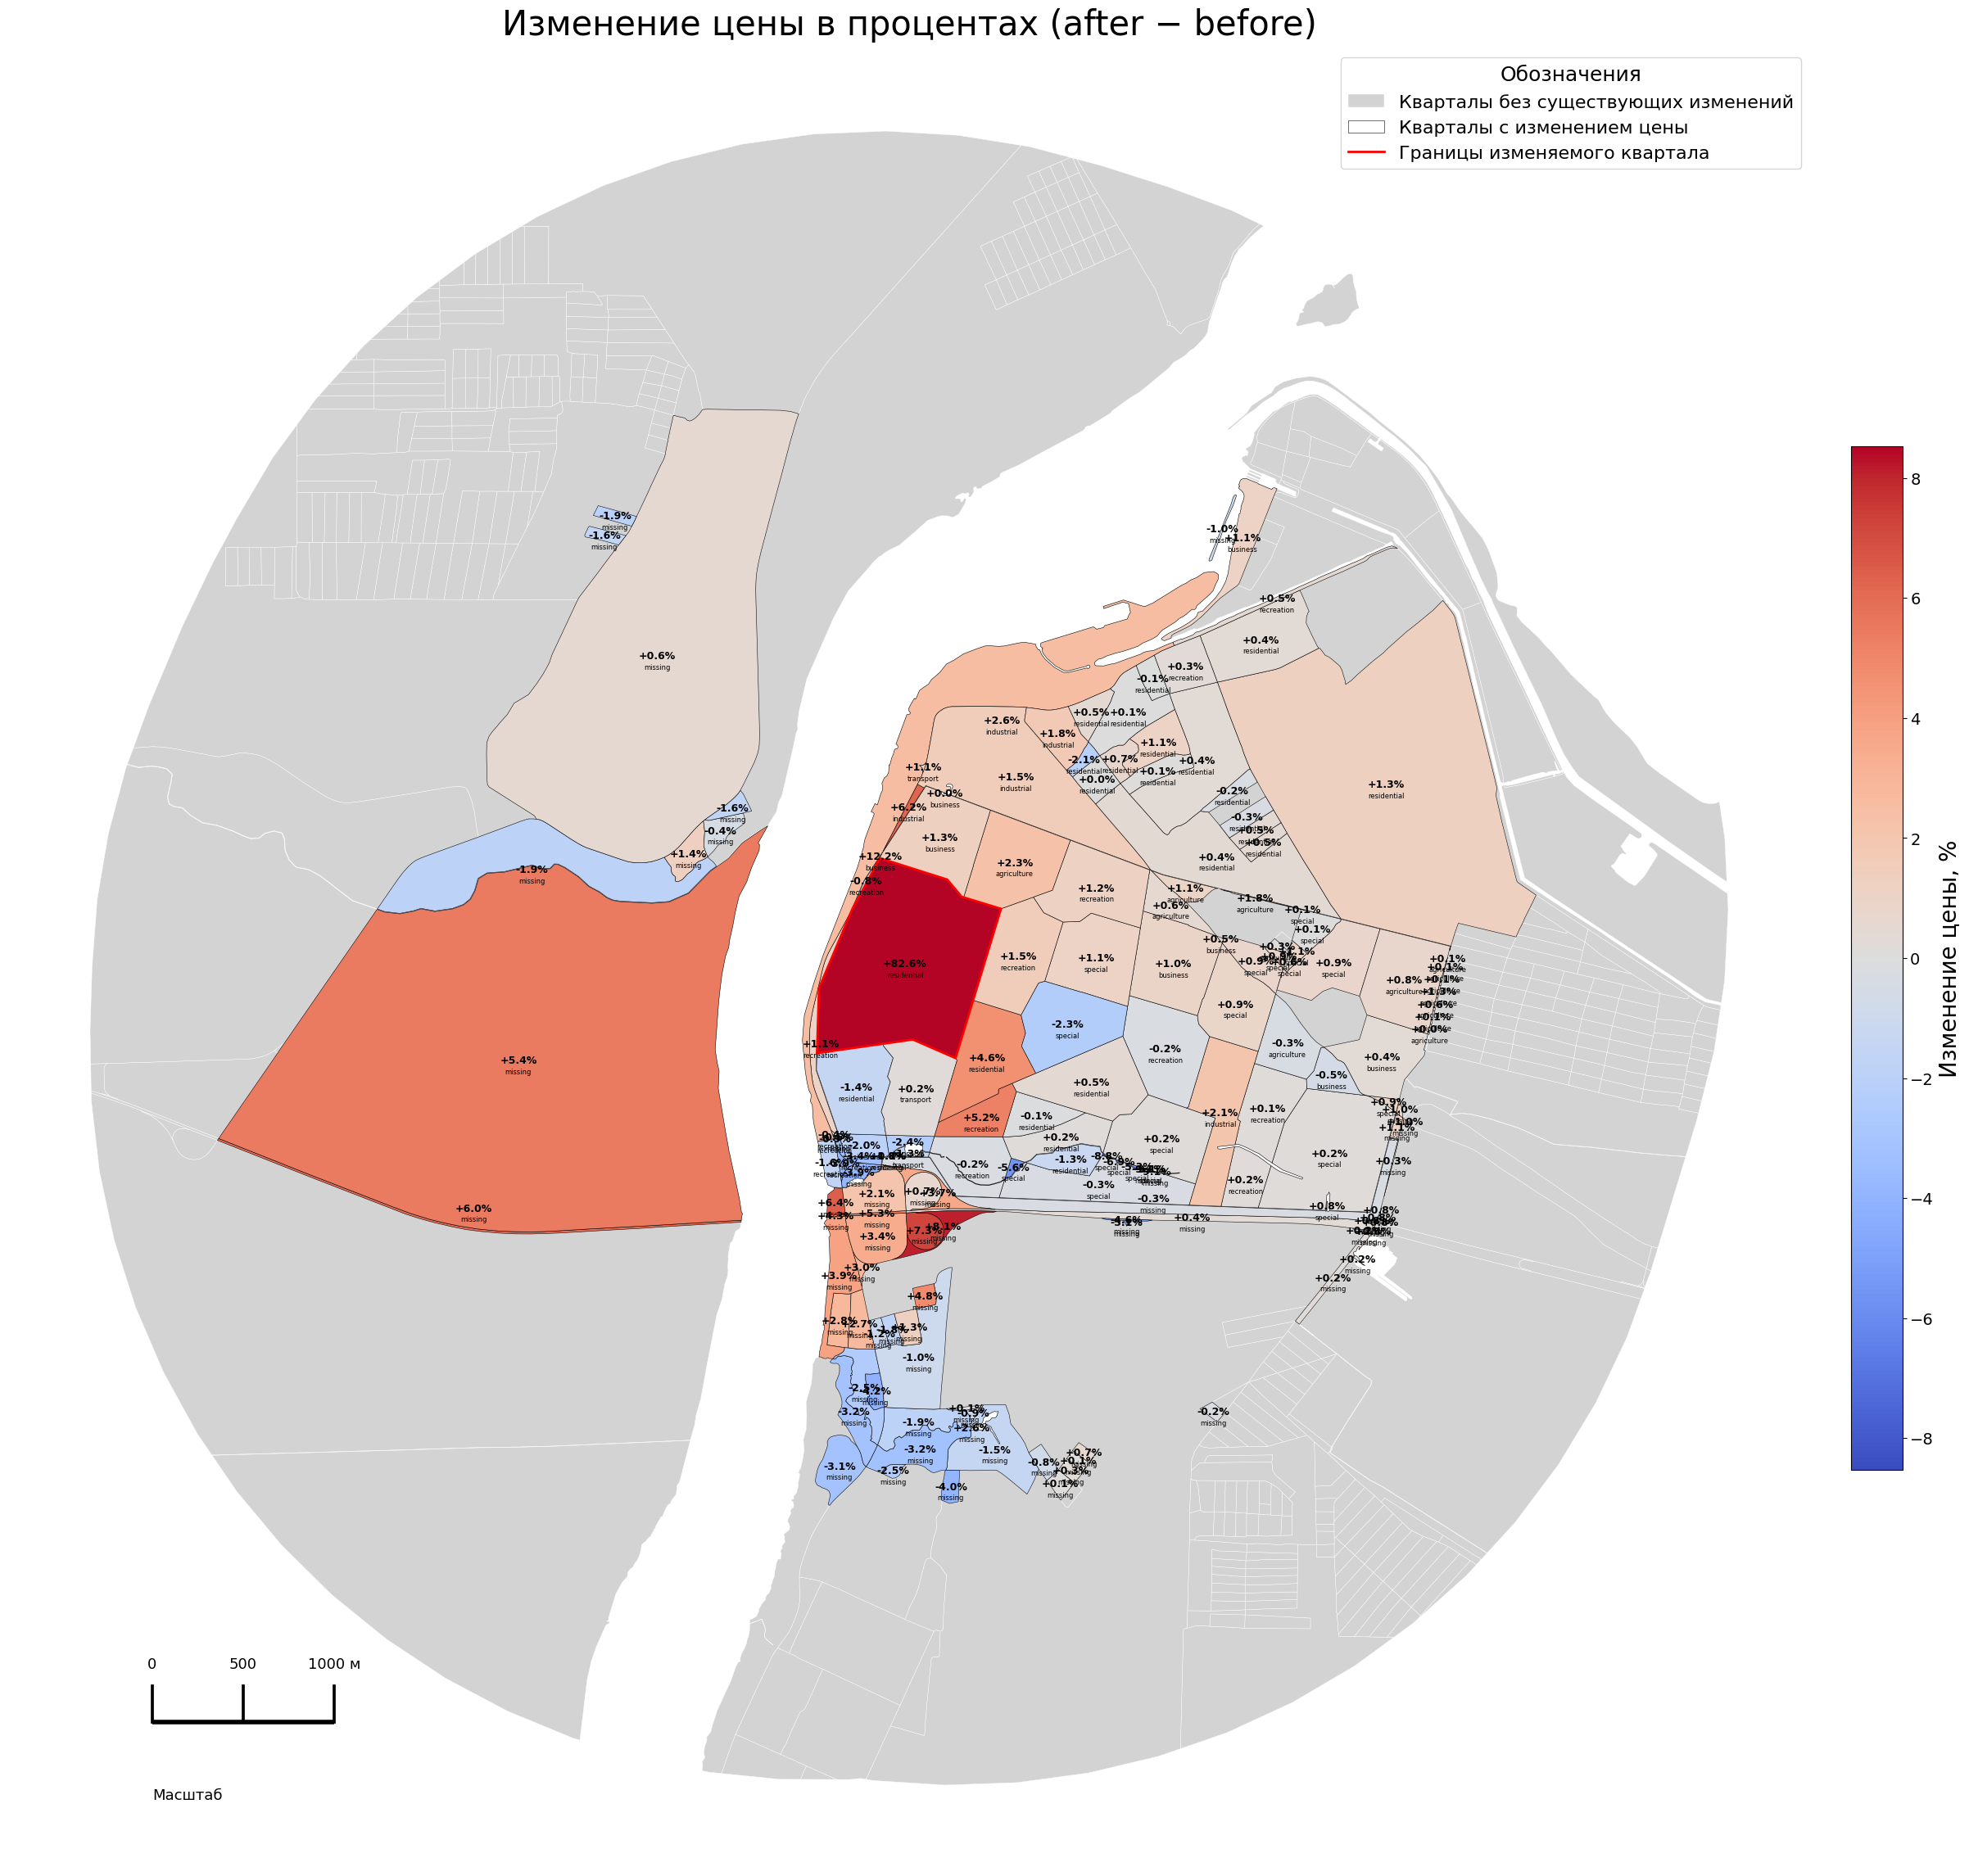


Статистика по кварталам в пределах буфера (|Δ₽| > 1e-09):
index | до (₽) → после (₽) | Δ₽ | Δ%
377 | 68 021 ₽ → 68 581 ₽ | +560 ₽ | +0.8%
387 | 63 880 ₽ → 64 407 ₽ | +526 ₽ | +0.8%
388 | 1 360 248 ₽ → 1 371 453 ₽ | +11 205 ₽ | +0.8%
1421 | 66 313 ₽ → 66 859 ₽ | +546 ₽ | +0.8%
1450 | 67 502 ₽ → 68 058 ₽ | +556 ₽ | +0.8%
1568 | 12 069 718 ₽ → 12 149 446 ₽ | +79 728 ₽ | +0.7%
1525 | 24 328 363 ₽ → 24 378 985 ₽ | +50 622 ₽ | +0.2%
1559 | 10 377 566 ₽ → 10 359 366 ₽ | -18 200 ₽ | -0.2%
614 | 1 343 985 ₽ → 1 274 796 ₽ | -69 189 ₽ | -5.1%
326 | 64 785 010 ₽ → 65 040 018 ₽ | +255 008 ₽ | +0.4%
378 | 3 414 569 ₽ → 3 258 248 ₽ | -156 321 ₽ | -4.6%
12 | 162 321 450 ₽ → 161 807 582 ₽ | -513 868 ₽ | -0.3%
325 | 158 462 519 ₽ → 157 956 184 ₽ | -506 336 ₽ | -0.3%
48 | 58 415 ₽ → 53 092 ₽ | -5 323 ₽ | -9.1%
49 | 57 246 ₽ → 52 029 ₽ | -5 217 ₽ | -9.1%
1451 | 3 138 156 ₽ → 3 146 303 ₽ | +8 147 ₽ | +0.3%
617 | 9 118 375 ₽ → 9 218 077 ₽ | +99 701 ₽ | +1.1%
2552 | 1 745 480 ₽ → 1 763 113 ₽ | +17 634 ₽ | +

In [9]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)

blocks_before = blocks
changes = {
    'land_use': 'LandUse.RESIDENTIAL',
    'share': 0.95,
    'footprint_area': 49039.24,
    'build_floor_area': 230279.19,
    'living_area': 155896.85,
    'population': 5168
}
target_idx = 62

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    model=model,
    target_idx=target_idx,
    figsize=(25, 35),
)

